In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Sklearn
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve)
from sklearn.preprocessing import label_binarize
import joblib

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1f2e',
    'axes.edgecolor':   '#2d3550',
    'axes.labelcolor':  '#c9d1e0',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'text.color':       '#c9d1e0',
    'grid.color':       '#2d3550',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
})

FAKE_COLOR = '#f04f4f'
REAL_COLOR = '#22c97a'
ACCENT     = '#4f8ef7'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# ── Load Combined Dataset ─────────────────────────────────
df = pd.read_csv('combined_dataset.csv')

# Ensure label is integer
df['label'] = df['label'].map(lambda x: 1 if str(x).lower() in ['1', 'fake'] else 0)

# Drop nulls
df = df.dropna(subset=['title', 'text'])
df = df.reset_index(drop=True)

print("=" * 45)
print(f"  Total Articles    : {len(df):,}")
print(f"  Real Articles (0) : {(df['label']==0).sum():,}")
print(f"  Fake Articles (1) : {(df['label']==1).sum():,}")
print(f"  Columns           : {list(df.columns)}")
print("=" * 45)
df.head()

  Total Articles    : 136,437
  Real Articles (0) : 66,393
  Fake Articles (1) : 70,044
  Columns           : ['title', 'text', 'label']


,title,text,label
0,Language culture significant.,effect company half long argue something cell ...,1
1,Medical reflect gas under action.,condition note behavior seat suddenly morning ...,1
2,Himself clearly would three audience task myself.,television agent follow yet home financial sim...,0
3,What do the protesters believe they are protes...,"written by Admin \nA victory for freedom, just...",1
4,"Rand Paul returns $620,000 to U.S. Treasury","Rand Paul returns $620,000 to U.S. Treasury 'I...",1


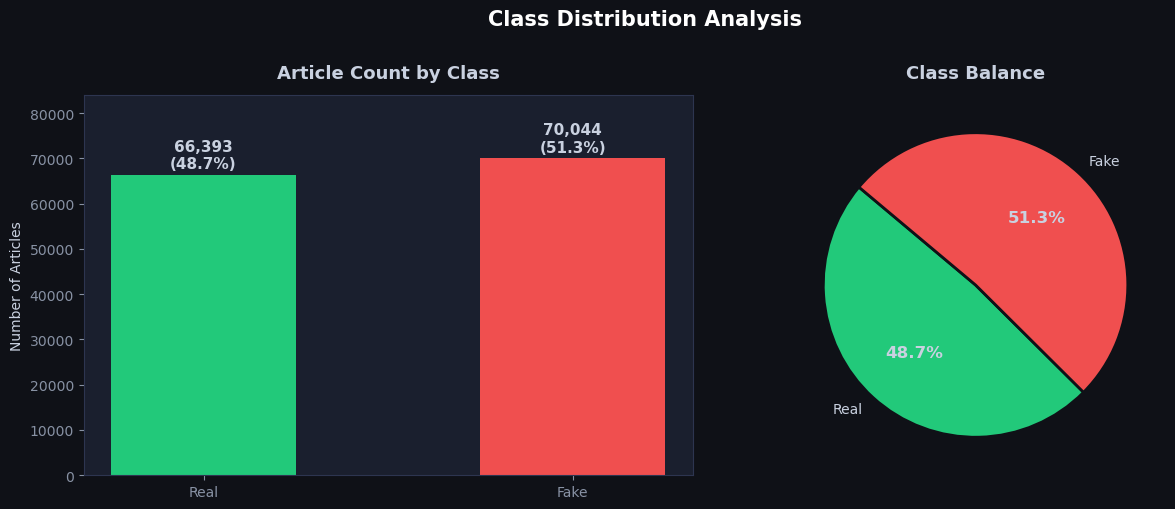

✅ Dataset is well balanced — no resampling needed!


In [3]:
# ── Class Distribution ────────────────────────────────────
counts = df['label'].value_counts().sort_index()
labels = ['Real', 'Fake']
colors = [REAL_COLOR, FAKE_COLOR]
total  = len(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution Analysis', fontsize=15, fontweight='bold', color='white', y=1.01)

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='none', width=0.5)
axes[0].set_title('Article Count by Class')
axes[0].set_ylabel('Number of Articles')
axes[0].set_ylim(0, max(counts.values) * 1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(counts.values)*0.02,
                 f'{val:,}\n({val/total*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Dataset is well balanced — no resampling needed!")

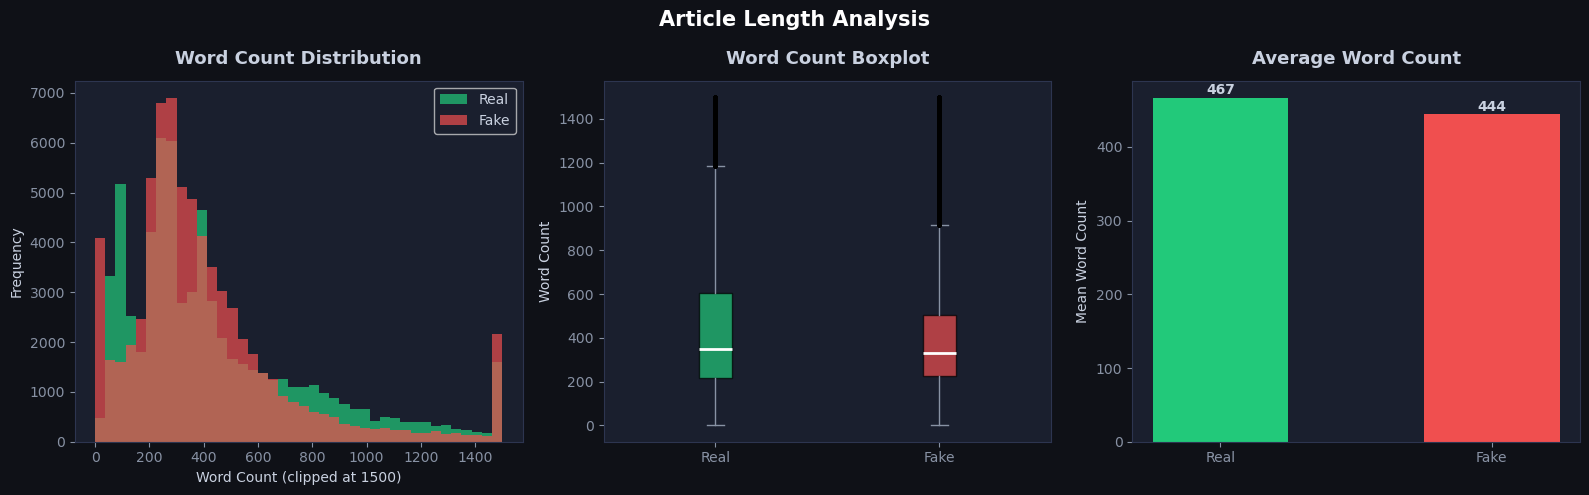

Average word count — Real: 467 | Fake: 444


In [4]:
# ── Article Length Analysis ───────────────────────────────
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['title_len']  = df['title'].apply(lambda x: len(str(x).split()))

real_wc = df[df['label']==0]['word_count']
fake_wc = df[df['label']==1]['word_count']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Article Length Analysis', fontsize=15, fontweight='bold', color='white')

# Histogram — word count
axes[0].hist(real_wc.clip(0, 1500), bins=40, color=REAL_COLOR, alpha=0.7, label='Real', edgecolor='none')
axes[0].hist(fake_wc.clip(0, 1500), bins=40, color=FAKE_COLOR, alpha=0.7, label='Fake', edgecolor='none')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count (clipped at 1500)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(
    [real_wc.clip(0,1500), fake_wc.clip(0,1500)],
    labels=['Real', 'Fake'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#8892a4'),
    capprops=dict(color='#8892a4'),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], [REAL_COLOR, FAKE_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Word Count Boxplot')
axes[1].set_ylabel('Word Count')

# Mean comparison bar
means = [real_wc.mean(), fake_wc.mean()]
bars  = axes[2].bar(['Real', 'Fake'], means, color=colors, edgecolor='none', width=0.5)
axes[2].set_title('Average Word Count')
axes[2].set_ylabel('Mean Word Count')
for bar, val in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('length_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"Average word count — Real: {real_wc.mean():.0f} | Fake: {fake_wc.mean():.0f}")

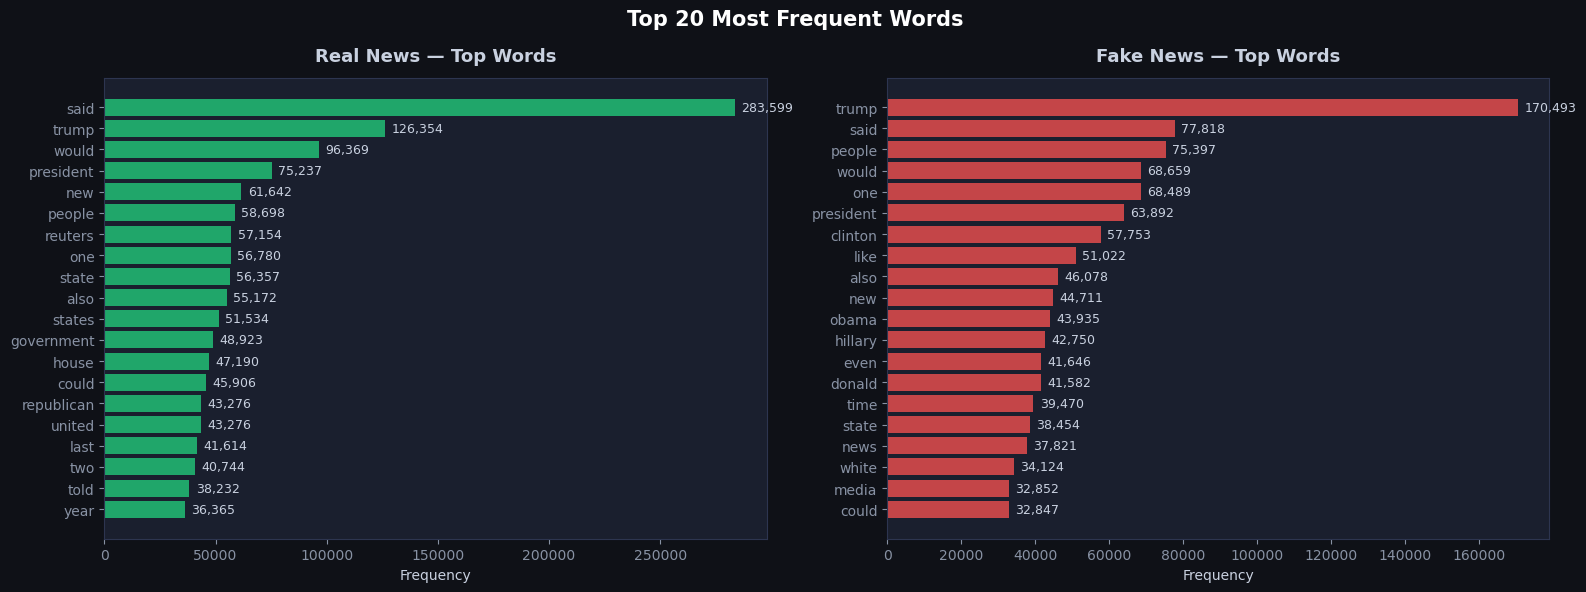

In [5]:
# ── Top Words per Class ───────────────────────────────────
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if w and w not in stop_words and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)

real_words = get_top_words(df[df['label']==0]['text'])
fake_words = get_top_words(df[df['label']==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Most Frequent Words', fontsize=15, fontweight='bold', color='white')

for ax, word_counts, color, title in zip(
    axes,
    [real_words, fake_words],
    [REAL_COLOR, FAKE_COLOR],
    ['Real News — Top Words', 'Fake News — Top Words']
):
    words, counts = zip(*word_counts)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=color, alpha=0.8, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    for bar, val in zip(bars, list(reversed(counts))):
        ax.text(bar.get_width() + max(counts)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [6]:
# ── Text Preprocessing ────────────────────────────────────
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

# Combine title + text
df['content'] = df['title'] + ' ' + df['text']
df['content_clean'] = df['content'].apply(clean_text)

# Preview
print("BEFORE cleaning:")
print(df['content'].iloc[0][:250])
print("\nAFTER cleaning:")
print(df['content_clean'].iloc[0][:250])
print(f"\n✅ Preprocessed {len(df):,} articles!")

BEFORE cleaning:
Language culture significant. effect company half long argue something cell contain management herself center drug gas guy drop TV run police Congress process guy thank win impact out return increase maybe why ground provide surface seven data instea

AFTER cleaning:
language culture significant effect company half long argue something cell contain management center drug gas guy drop tv run police congress process guy thank win impact return increase maybe ground provide surface seven data instead view behavior s

✅ Preprocessed 136,437 articles!


In [7]:
# ── TF-IDF Vectorization + Split ─────────────────────────
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training set : {X_train_tfidf.shape}")
print(f"Testing set  : {X_test_tfidf.shape}")
print(f"Train labels : {dict(y_train.value_counts().sort_index())}")
print(f"Test labels  : {dict(y_test.value_counts().sort_index())}")

Training set : (109149, 50000)
Testing set  : (27288, 50000)
Train labels : {0: np.int64(53114), 1: np.int64(56035)}
Test labels  : {0: np.int64(13279), 1: np.int64(14009)}


In [8]:
# ── Logistic Regression Training ─────────────────────────
lr = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred      = lr.predict(X_test_tfidf)
y_pred_prob = lr.predict_proba(X_test_tfidf)[:, 1]

print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

  Accuracy  : 90.49%
              precision    recall  f1-score   support

        Real       0.91      0.90      0.90     13279
        Fake       0.90      0.91      0.91     14009

    accuracy                           0.90     27288
   macro avg       0.90      0.90      0.90     27288
weighted avg       0.90      0.90      0.90     27288



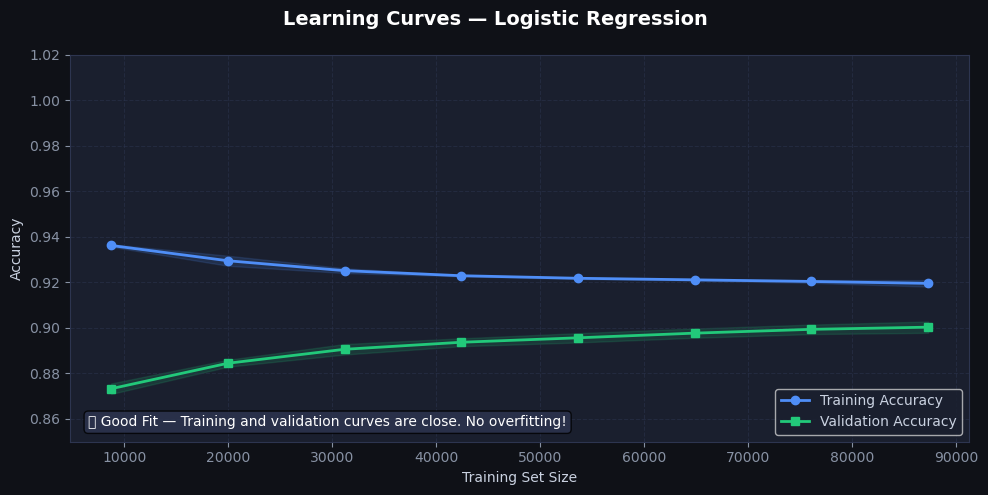


Train Accuracy : 91.95%
Val Accuracy   : 90.03%
Gap            : 1.92%
✅ Good Fit — Training and validation curves are close. No overfitting!


In [9]:
# ── Learning Curves ───────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_tfidf, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Learning Curves — Logistic Regression', fontsize=14, fontweight='bold', color='white')

ax.plot(train_sizes, train_mean, 'o-', color=ACCENT,      label='Training Accuracy',   linewidth=2)
ax.plot(train_sizes, val_mean,   's-', color=REAL_COLOR,  label='Validation Accuracy', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color=ACCENT)
ax.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.15, color=REAL_COLOR)

ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.02)
ax.legend(loc='lower right')
ax.grid(True)

gap = abs(train_mean[-1] - val_mean[-1])
if gap < 0.02:
    diagnosis = "✅ Good Fit — Training and validation curves are close. No overfitting!"
elif gap < 0.05:
    diagnosis = "⚠️ Slight Overfitting — Consider adding more data or regularization."
else:
    diagnosis = "❌ Overfitting — Large gap between training and validation accuracy."

ax.text(0.02, 0.04, diagnosis, transform=ax.transAxes,
        fontsize=10, color='white',
        bbox=dict(boxstyle='round', facecolor='#2d3550', alpha=0.8))

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"\nTrain Accuracy : {train_mean[-1]*100:.2f}%")
print(f"Val Accuracy   : {val_mean[-1]*100:.2f}%")
print(f"Gap            : {gap*100:.2f}%")
print(diagnosis)

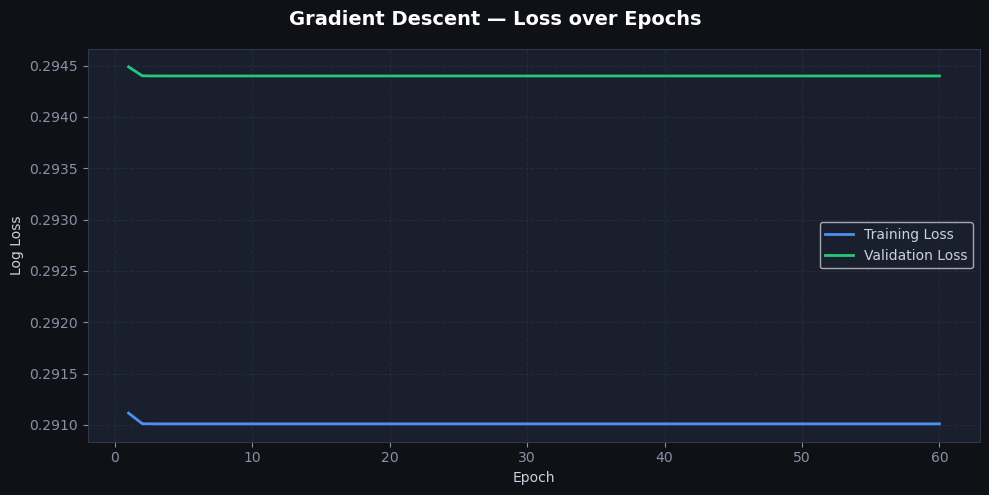

Final Train Loss : 0.2910
Final Val Loss   : 0.2944


In [10]:
# ── Gradient Descent Visualization ───────────────────────
# Use SGDClassifier with log loss = same as Logistic Regression
# but lets us track loss per iteration

sgd = SGDClassifier(
    loss='log_loss', max_iter=1, warm_start=True,
    random_state=42, learning_rate='optimal'
)

train_losses, val_losses = [], []
EPOCHS = 60

for epoch in range(EPOCHS):
    sgd.fit(X_train_tfidf, y_train)
    train_prob = sgd.predict_proba(X_train_tfidf)
    val_prob   = sgd.predict_proba(X_test_tfidf)

    # Log loss manually
    eps = 1e-10
    t_loss = -np.mean(
        y_train * np.log(train_prob[:,1]+eps) +
        (1-y_train) * np.log(train_prob[:,0]+eps)
    )
    v_loss = -np.mean(
        y_test * np.log(val_prob[:,1]+eps) +
        (1-y_test) * np.log(val_prob[:,0]+eps)
    )
    train_losses.append(t_loss)
    val_losses.append(v_loss)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gradient Descent — Loss over Epochs', fontsize=14, fontweight='bold', color='white')

ax.plot(range(1, EPOCHS+1), train_losses, color=ACCENT,     label='Training Loss',   linewidth=2)
ax.plot(range(1, EPOCHS+1), val_losses,   color=REAL_COLOR, label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('gradient_descent.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"Final Train Loss : {train_losses[-1]:.4f}")
print(f"Final Val Loss   : {val_losses[-1]:.4f}")

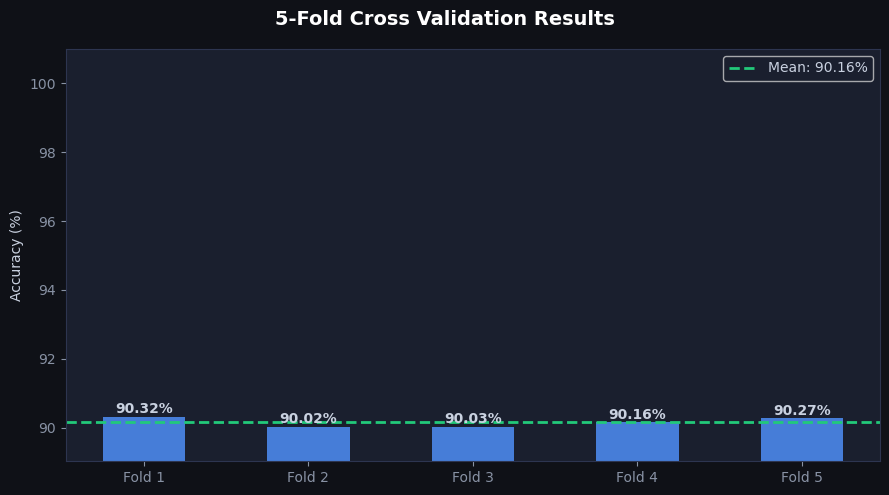

CV Scores  : ['90.32%', '90.02%', '90.03%', '90.16%', '90.27%']
Mean       : 90.16%
Std Dev    : 0.12%
✅ Very consistent across folds — model is stable!


In [11]:
# ── Cross Validation (Underfitting/Overfitting Check) ─────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_tfidf, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('5-Fold Cross Validation Results', fontsize=14, fontweight='bold', color='white')

bars = ax.bar([f'Fold {i+1}' for i in range(5)],
              cv_scores * 100,
              color=ACCENT, alpha=0.85, edgecolor='none', width=0.5)
ax.axhline(cv_scores.mean()*100, color=REAL_COLOR,
           linestyle='--', linewidth=2,
           label=f'Mean: {cv_scores.mean()*100:.2f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(cv_scores.min()*100 - 1, 101)
ax.legend()
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val*100:.2f}%', ha='center',
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"CV Scores  : {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"Mean       : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev    : {cv_scores.std()*100:.2f}%")

if cv_scores.std() < 0.01:
    print("✅ Very consistent across folds — model is stable!")
else:
    print("⚠️ High variance across folds — consider more data.")